# NBA Points per Game Differential

In [32]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Figure, Axes
import numpy as np
import os
from PIL import Image

# Pull data from the 2024-2025 NBA season
games_25 = leaguegamefinder.LeagueGameFinder(season_nullable='2024-25', season_type_nullable='Regular Season')
# get data frame from returned list
df_25: pd.DataFrame = games_25.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_25.to_csv('season_raw_25.csv' ,index=False)


# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv('season_raw_26.csv' ,index=False)

In [17]:
# Keep Only columns that you need for each respective Season
# 2024-25
team_stats_25 = df_25[['SEASON_ID','TEAM_ABBREVIATION', 'WL', 'PTS', 'FG3M']]
# Change Season ID Value
team_stats_25['SEASON_ID'] = '2024-25'
# Write to csv for easy viewing
team_stats_25.to_csv('season_breakdown_25.csv', index=False)

# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'WL', 'PTS', 'FG3M']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv('season_breakdown_26.csv', index=False)

In [18]:
summary_25 = (
    team_stats_25.groupby('TEAM_ABBREVIATION')
    .agg(
        games=('WL', 'count'),
        wins=('WL', lambda s: (s=='W').sum()),
        points=('PTS', 'mean'),
        threes=('FG3M', 'sum') 
    )
).reset_index()

In [19]:
summary_26 = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        games=('WL', 'count'),
        wins=('WL', lambda s: (s=='W').sum()),
        points=('PTS', 'mean'),
        threes=('FG3M', 'sum') 
    )
).reset_index()

In [20]:
summary_25['SEASON_ID'] = '2024-25'
summary_26['SEASON_ID'] = '2025-26'

summary_25.to_csv('season_agg_25.csv', index=False)
summary_26.to_csv('season_agg_26.csv', index=False)

In [21]:
summary_25.sort_values('TEAM_ABBREVIATION',ascending=False)
summary_26.sort_values('TEAM_ABBREVIATION',ascending=False)

print(summary_25.head())
print(summary_26.head())

# summary = pd.concat([summary_25, summary_26], axis=0)

# summary.sort_values('TEAM_ABBREVIATION',ascending=False)
# print(summary.head())
# summary.to_csv('sum.csv', index=False)

  TEAM_ABBREVIATION  games  wins      points  threes SEASON_ID
0               ATL     82    40  118.182927    1107   2024-25
1               BKN     82    26  105.109756    1113   2024-25
2               BOS     82    61  116.268293    1457   2024-25
3               CHA     82    19  105.097561    1065   2024-25
4               CHI     82    39  117.804878    1266   2024-25
  TEAM_ABBREVIATION  games  wins      points  threes SEASON_ID
0               ATL     82    46  118.463415    1201   2025-26
1               BKN     82    20  105.926829    1073   2025-26
2               BOS     82    56  114.853659    1268   2025-26
3               CHA     82    44  116.012195    1343   2025-26
4               CHI     82    31  116.304878    1169   2025-26


In [14]:
# Query syntax
points_25 = summary.query("SEASON_ID == '2024-25'")['points']
points_26 = summary.query("SEASON_ID == '2025-26'")['points']

NameError: name 'summary' is not defined

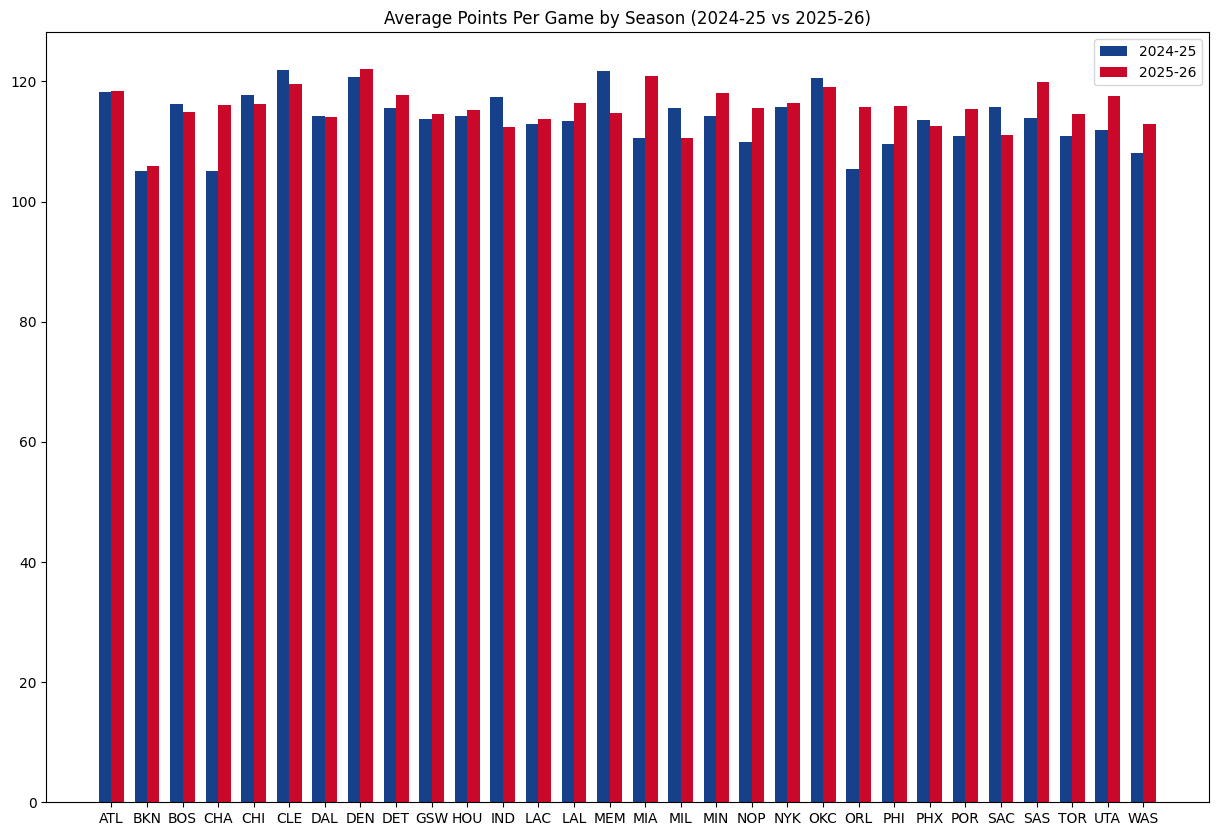

In [22]:
# summary.sort_values('TEAM_ABBREVIATION',ascending=False).plot(
#     x='TEAM_ABBREVIATION', y=[summary.query("SEASON_ID == '2024-25'")['points'], summary.query("SEASON_ID == '2025-26'")['points']], kind='bar',
#     legend=True, figsize=(12,5), title='Average Points Per Game (2024-25 vs 2025-26)'
# )

teams = list(summary_25['TEAM_ABBREVIATION'])
x = np.arange(len(teams))  # Numerical locations for labels
width = 0.35  # Width of each bar

fig, ax = plt.subplots(figsize =(15, 10))
# Shift the first bar left and the second bar right
ax.bar(x - width/2, summary_25['points'], width, label='2024-25', color='#17408B')
ax.bar(x + width/2, summary_26['points'], width, label='2025-26', color='#C9082A')

ax.set_title("Average Points Per Game by Season (2024-25 vs 2025-26)")
ax.set_xticks(x)
ax.set_xticklabels(teams)
ax.legend()
plt.savefig('plots/Avg_Points.png')
plt.show()

# barWidth = 0.25
# fig = plt.subplots(figsize =(12, 8)) 
# plt.bar(summary_25['TEAM_ABBREVIATION'], summary_25['points'], width = barWidth, label = '2024-25')
# plt.bar(summary_26['TEAM_ABBREVIATION'], summary_26['points'], width = barWidth, label = '2025-26')
# plt.ylabel('Points')
# plt.tight_layout()
# plt.legend()
# plt.savefig('Avg_Points.png')
# plt.show()

In [24]:
#print(summary_25.head())
#print(summary_26.head())

# Filter Data to just contain the Team Name and the Points
season_25_points = summary_25[['TEAM_ABBREVIATION', 'points']] # 2024-25 season
season_26_points = summary_26[['TEAM_ABBREVIATION', 'points']] # 2025-26 season
# Simplify the Column names
season_25_points.columns = ["teams", "points_25"]
season_26_points.columns = ["teams", "points_26"]
#print(season_25_points.head())
#print(season_26_points.head())

combine_season = pd.merge(season_25_points, season_26_points, how='inner', on=['teams'])
#print(combine_season.head())

# Create new column with the differences between point averages of the '25 and '26 seasons
combine_season['p_diff'] = -(combine_season['points_25'] - combine_season['points_26'])

# Sort the data from greatest point average difference to least
combine_season = combine_season.sort_values('p_diff', ascending=False)
print(combine_season.head())

   teams   points_25   points_26     p_diff
3    CHA  105.097561  116.012195  10.914634
21   ORL  105.426829  115.743902  10.317073
15   MIA  110.597561  120.865854  10.268293
22   PHI  109.609756  115.878049   6.268293
26   SAS  113.926829  119.829268   5.902439


In [78]:
def plot_nba_logo(fig: Figure, ax: Axes):
    # Path to NBA logo
    logo_path = os.path.join('logos', 'compressed_NBA_logo.png')
    # Read image into Numpy array
    img = plt.imread(logo_path)
    # Adjust 'zoom' to scale your image up or down
    imagebox = OffsetImage(img, zoom=1)

    anno_box = AnnotationBbox(imagebox, xy=(0.225, 1.05), xycoords='axes fraction', 
                              box_alignment=(0, 1), frameon=False)
    ax.add_artist(anno_box)


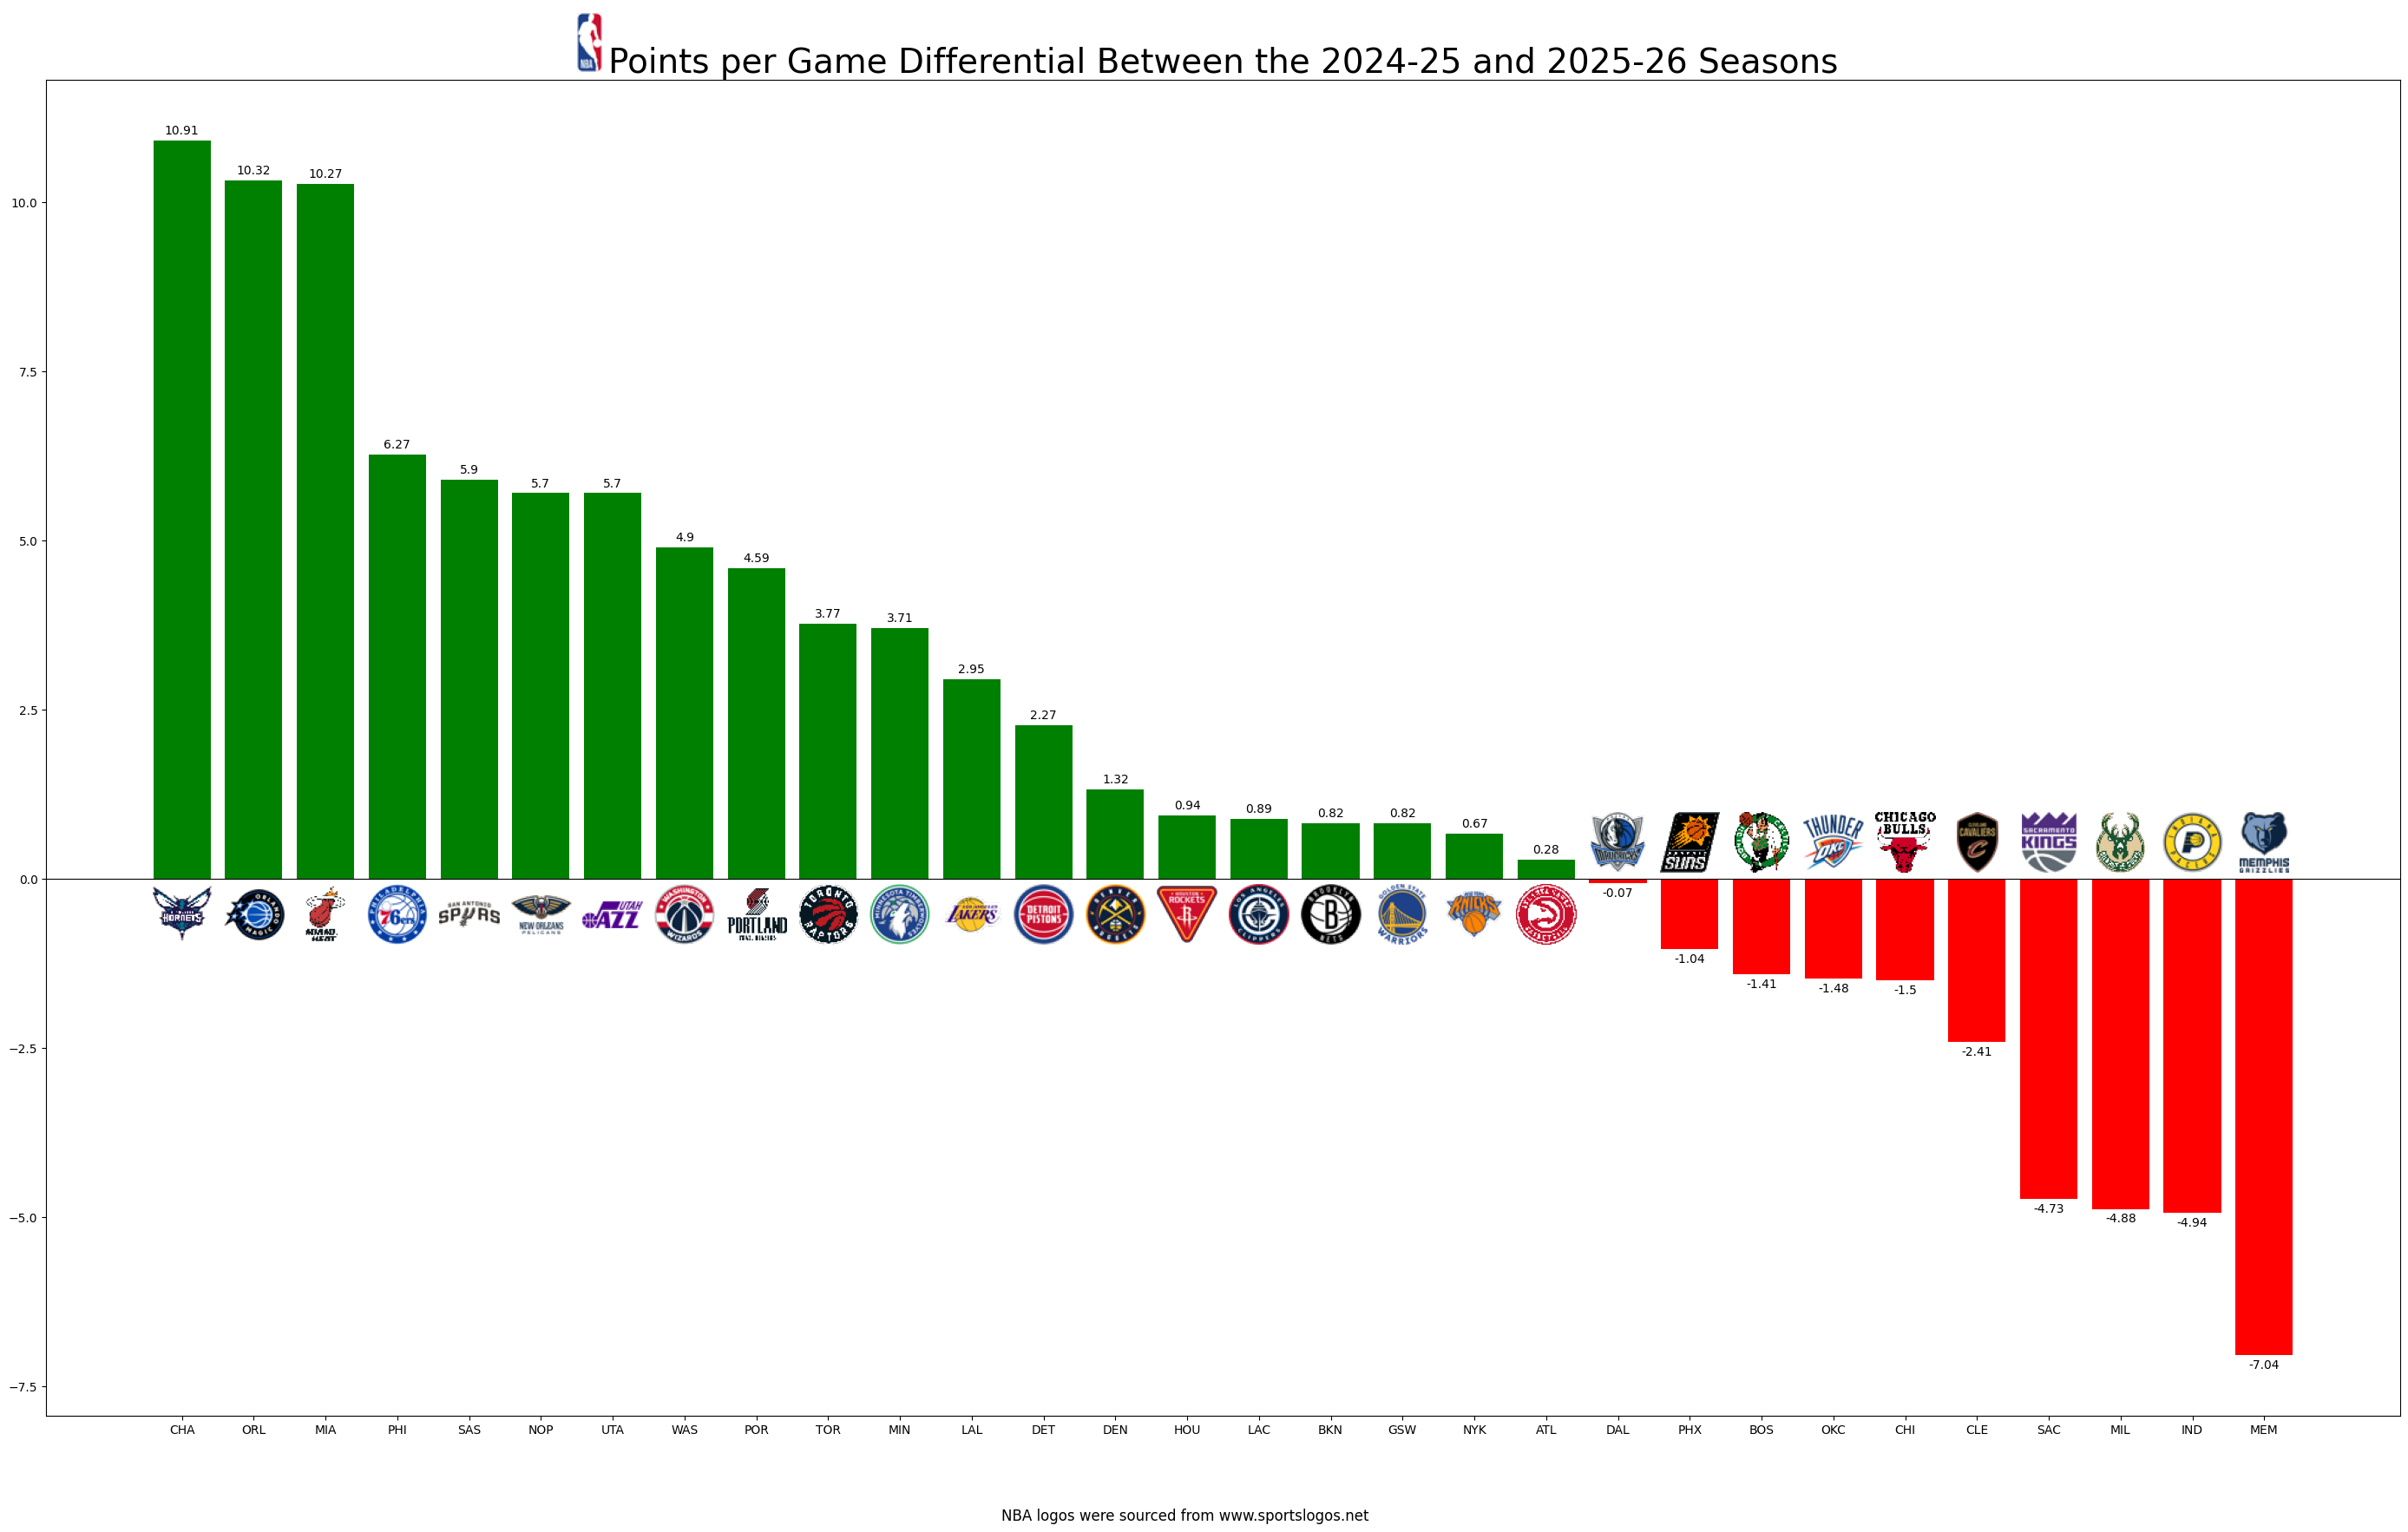

In [79]:
colors = ['red' if p < 0 else 'green' for p in combine_season['p_diff']]
fig, ax = plt.subplots(figsize =(35, 20))
bars = ax.bar(combine_season['teams'], round(combine_season['p_diff'], 2), color=colors, )
# ax.set_position([0.05, 0.05, 0.95, 0.85])

# Add Team Logos to the Bar Graph

# get tick labels of bar graph
bar_labels = ax.get_xticklabels()
# Loop through Bars and Labels
for bar, label in zip(bars, bar_labels):
    # Get Team Abbreviated Label
    team = label.get_text()
    # Get X Location
    x_pos = bar.get_x() + bar.get_width() / 2.0  # Center x-coordinate of the bar
    y_pos = 0                                    # Base of the bar (y=0)

    # Convert image to Offest Image
    # Get path to image based of of team name
    img_path = os.path.join('logos', f'compressed_{team}_logo.png')
    # im = Image.open(img_path)
    # im = im.thumbnail(size=(200,200))
    # Read image into Numpy array
    img = plt.imread(img_path)
    # Adjust 'zoom' to scale your image up or down
    imagebox = OffsetImage(img)

    xybox_val = (0, -30)
    if bar.get_height() < 0:
        xybox_val = (0, 30)

    # Create the AnnotationBbox container
    # 'xybox=(0, -20)' shifts the image 20 points downwards below the base line
    ab = AnnotationBbox(
        imagebox, 
        xy=(x_pos, y_pos),
        xybox=xybox_val,
        xycoords='data',
        boxcoords='offset points',
        frameon=False  # Removes the border box around the image
    )
    
    # Add the image annotation to the axes
    ax.add_artist(ab)

plt.axhline(0, color='black', linewidth=0.8) # Add a line at y=0 for clarity
plt.title("Points per Game Differential Between the 2024-25 and 2025-26 Seasons", fontsize=28)
ax.bar_label(bars, padding=3)
plt.figtext(0.5, 0.05, "NBA logos were sourced from www.sportslogos.net", 
            wrap=True, horizontalalignment='center', fontsize=12)
plot_nba_logo(fig, ax)
plt.savefig('plots/Points_Diff.png')
plt.show()

In [70]:
from PIL import Image
import csv

files = os.listdir('logos')
del_list = [file for file in files if file.startswith('compressed')]
for d in del_list:
    path = os.path.join('logos', d)
    os.remove(path)

files = os.listdir('logos')
images = [file for file in files if file.endswith('png')]
# for i in images:
#     print(os.path.join('logos',i))

with open("Logo_dimensions.csv", mode="a", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(['Team', 'Width', 'Height'])  # Writes the entire iterable of lists

for image in images:
    img = Image.open(os.path.join('logos',image))
    width, height = img.size
    # Open file and write all rows at once
    with open("Logo_dimensions.csv", mode="a", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow([image[:3], width, height])  # Writes the entire iterable of lists

    img.thumbnail(size=(50,50))
    img.save(os.path.join('logos','compressed_' + image), optimize=True, quality=85)
    #img.save(os.path.join('logos','compressed_' + image), optimize=True, compress_level=9)